# Wikipedia as a Sensor: Detecting Real-World Events from Edit Anomalies

Testing whether unusual Wikipedia editing behavior — edit volume, revert rate,
editor churn — corresponds to real-world events and controversy.

Full methodology and honest conclusions are in `docs/part1_prereg_results.md`
and `docs/part2_posthoc_results.md`; this notebook is the visual companion to
those write-ups. Column definitions and every judgment call behind them are in
`docs/data_dictionary.md`.

**Structure:**
1. Setup
2. Raw activity time series, with pre-registered event dates marked
3. Part 1 — pre-registered permutation test results (confirmatory)
4. Part 2 — post-hoc rescaling attempts and why they didn't help (exploratory)
5. Conclusion


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

ARTICLES = {
    "Kyle Rittenhouse": {
        "slug": "rittenhouse",
        "events": [pd.Timestamp("2021-11-19", tz="UTC")],
    },
    "Depp v. Heard": {
        "slug": "depp_heard",
        "events": [pd.Timestamp("2022-06-01", tz="UTC")],
    },
    "Dobbs v. Jackson": {
        "slug": "dobbs",
        "events": [pd.Timestamp("2022-05-02", tz="UTC"), pd.Timestamp("2022-06-24", tz="UTC")],
    },
}

DATA_DIR = "data"

def load_article(slug):
    """Load an article's daily scored data plus both post-hoc composite variants."""
    df = pd.read_csv(f"{DATA_DIR}/{slug}_scored.csv", parse_dates=["timestamp"])
    v2 = pd.read_csv(f"{DATA_DIR}/{slug}_v2.csv", parse_dates=["timestamp"])
    v3 = pd.read_csv(f"{DATA_DIR}/{slug}_v3.csv", parse_dates=["timestamp"])
    df["anomaly_score_v2"] = v2["anomaly_score_v2"]
    df["anomaly_score_v3"] = v3["anomaly_score_v3"]
    return df

articles = {name: load_article(cfg["slug"]) for name, cfg in ARTICLES.items()}
for name, df in articles.items():
    print(f"{name}: {len(df)} days, {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")


Kyle Rittenhouse: 2116 days, 2020-08-26 to 2026-06-11
Depp v. Heard: 1612 days, 2022-04-15 to 2026-09-12
Dobbs v. Jackson: 1947 days, 2021-05-17 to 2026-09-14


## Raw activity, with pre-registered event dates marked

Dashed red lines mark the dates registered *before* any anomaly detection was
run (see `docs/part1_prereg_results.md`). Note how visually different the
three articles' reactions are — this difference is the whole reason a single
composite score struggles later on.

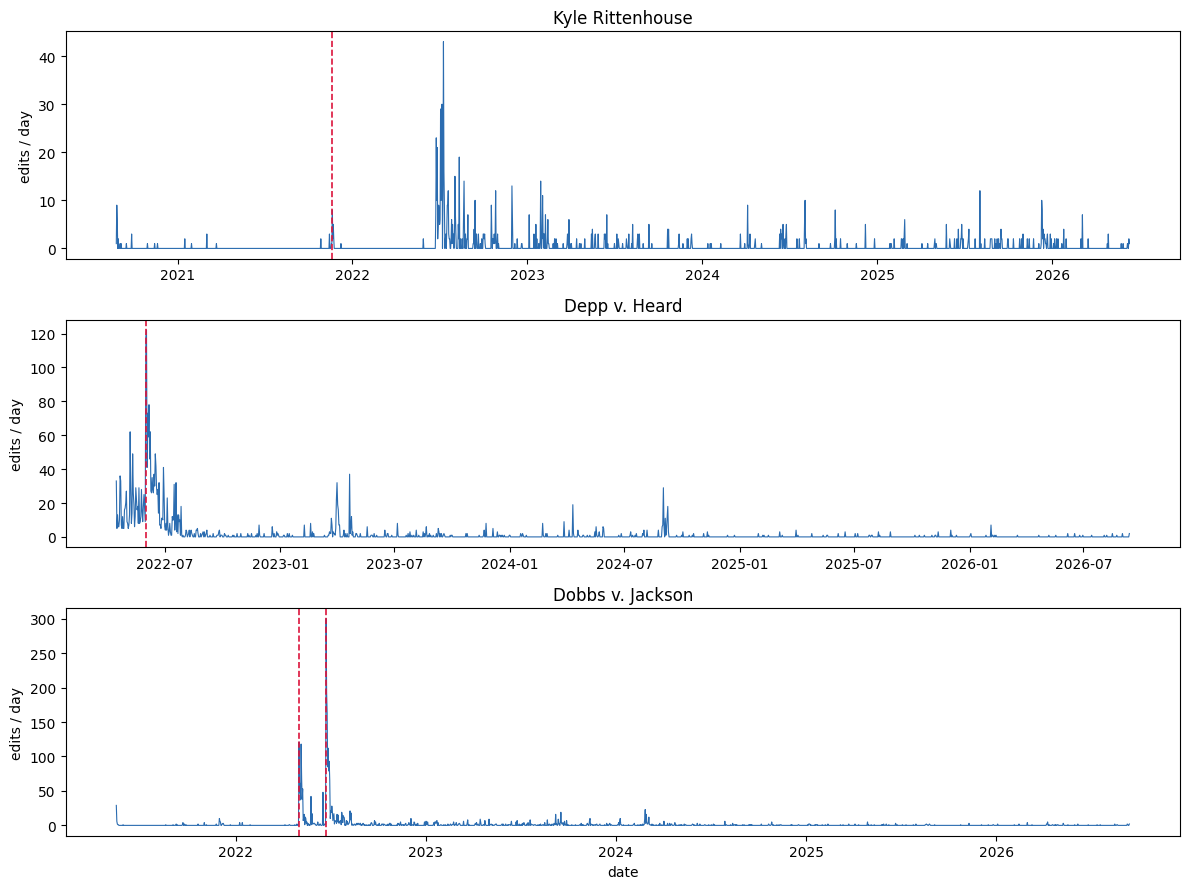

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for ax, (name, cfg) in zip(axes, ARTICLES.items()):
    df = articles[name]
    ax.plot(df["timestamp"], df["edits_count"], color="#2b6cb0", lw=0.8)
    for e in cfg["events"]:
        ax.axvline(e, color="crimson", ls="--", lw=1.2)
    ax.set_title(name)
    ax.set_ylabel("edits / day")

axes[-1].set_xlabel("date")
fig.tight_layout()
plt.show()


## Part 1 — Pre-registered validation (confirmatory)

The equal-weighted `anomaly_score` (mean of `z_edits_count`, `z_revert_rate`,
`z_editor_churn`, each z-scored against that article's own baseline,
excluding a ±3 day window around every registered event) tested against
10,000 permuted random windows per event. Full numbers and the written
conclusion are in `docs/part1_prereg_results.md`; summarized here.

In [3]:
prereg = pd.read_csv(f"{DATA_DIR}/prereg_test_results.csv")
display_cols = ["article", "event_date", "signal", "observed_max", "p_value"]
prereg[display_cols].sort_values(["article", "event_date", "signal"])


,article,event_date,signal,observed_max,p_value
4,Depp v. Heard,2022-06-01,anomaly_score,7.1447,0.0001
7,Depp v. Heard,2022-06-01,z_editor_churn,2.0985,0.4138
5,Depp v. Heard,2022-06-01,z_edits_count,19.8477,0.0003
6,Depp v. Heard,2022-06-01,z_revert_rate,0.1474,0.3062
8,Dobbs,2022-05-02,anomaly_score,7.8133,0.0012
11,Dobbs,2022-05-02,z_editor_churn,3.1362,0.3561
9,Dobbs,2022-05-02,z_edits_count,20.0034,0.0015
10,Dobbs,2022-05-02,z_revert_rate,4.2905,0.1628
12,Dobbs,2022-06-24,anomaly_score,17.5925,0.0001
15,Dobbs,2022-06-24,z_editor_churn,2.7893,0.3664


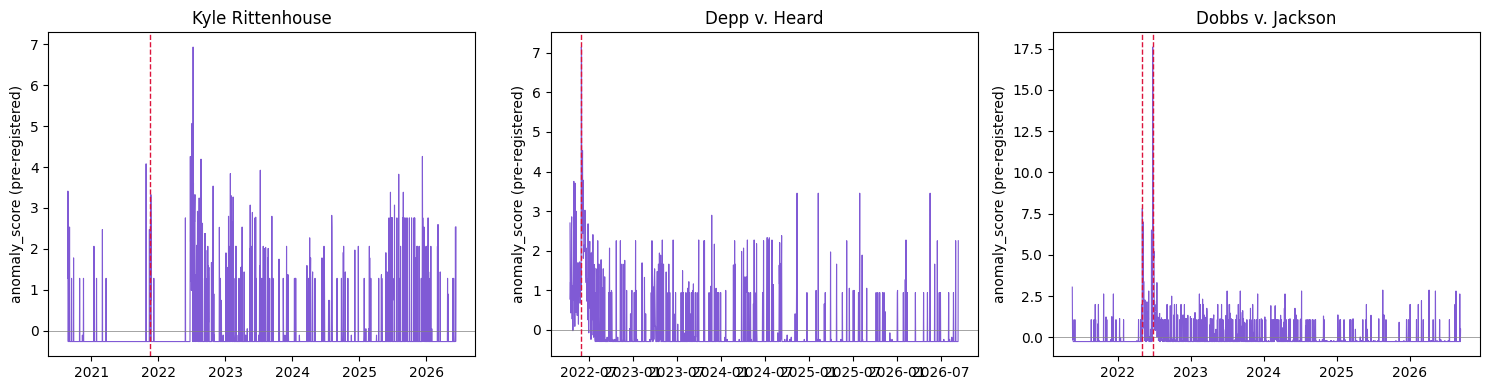

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, cfg) in zip(axes, ARTICLES.items()):
    df = articles[name]
    ax.plot(df["timestamp"], df["anomaly_score"], color="#805ad5", lw=0.8)
    ax.axhline(0, color="gray", lw=0.5)
    for e in cfg["events"]:
        ax.axvline(e, color="crimson", ls="--", lw=1)
    ax.set_title(name)
    ax.set_ylabel("anomaly_score (pre-registered)")

fig.tight_layout()
plt.show()


**Reading these plots:** Depp v. Heard and both Dobbs dates land right on
top of, or just after, sharp `anomaly_score` peaks. Rittenhouse's verdict line
sits near a comparatively modest bump — dwarfed later in the series by a much
larger spike in July 2022 that turned out to be unrelated editorial
restructuring, not a real-world event (see the data dictionary and Part 1
write-up for the full explanation). This is *why* the pre-registered test
narrowly missed significance for Rittenhouse (p=0.052) despite `z_revert_rate`
alone catching it clearly (p=0.031).

## Part 2 — Post-hoc rescaling attempts (exploratory)

Two attempts were made, **after** seeing the Part 1 results, to fix the
composite score's scale-dominance problem (`z_edits_count` runs far larger
than the other two signals for high-volume events, so it dominates an
"equal-weight" average in practice). Both are reported here even though
neither improved on the pre-registered result — see
`docs/part2_posthoc_results.md` for the full reasoning.

In [5]:
v2_results = pd.read_csv(f"{DATA_DIR}/posthoc_test_results.csv")
v3_results = pd.read_csv(f"{DATA_DIR}/posthoc_v3_test_results.csv")

raw_z = prereg[prereg["signal"] == "anomaly_score"][["article", "event_date", "p_value"]].rename(columns={"p_value": "Part 1: raw z (pre-registered)"})
percentile = v2_results[v2_results["signal"] == "anomaly_score_v2"][["article", "event_date", "p_value"]].rename(columns={"p_value": "Part 2a: percentile"})
winsorized = v3_results[v3_results["signal"] == "anomaly_score_v3"][["article", "event_date", "p_value"]].rename(columns={"p_value": "Part 2b: winsorized (cap=5)"})

comparison = raw_z.merge(percentile, on=["article", "event_date"]).merge(winsorized, on=["article", "event_date"])
comparison


,article,event_date,Part 1: raw z (pre-registered),Part 2a: percentile,Part 2b: winsorized (cap=5)
0,Rittenhouse,2021-11-19,0.0520,0.083792,0.057094
1,Depp v. Heard,2022-06-01,0.0001,0.131587,0.032297
2,Dobbs,2022-05-02,0.0012,0.055894,0.008699
3,Dobbs,2022-06-24,0.0001,0.055294,0.010499


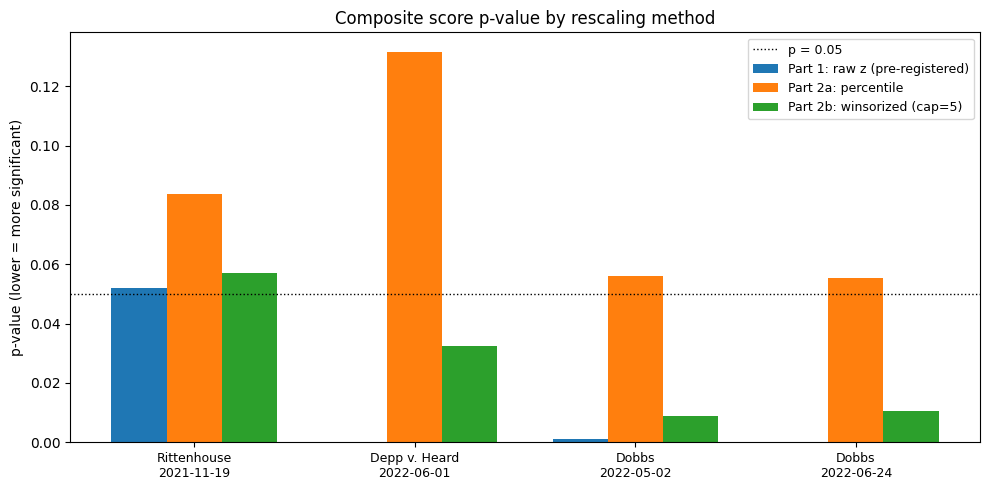

In [6]:
comparison["label"] = comparison["article"] + "\n" + comparison["event_date"]
x = range(len(comparison))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width for i in x], comparison["Part 1: raw z (pre-registered)"], width, label="Part 1: raw z (pre-registered)")
ax.bar(x, comparison["Part 2a: percentile"], width, label="Part 2a: percentile")
ax.bar([i + width for i in x], comparison["Part 2b: winsorized (cap=5)"], width, label="Part 2b: winsorized (cap=5)")
ax.axhline(0.05, color="black", ls=":", lw=1, label="p = 0.05")
ax.set_xticks(list(x))
ax.set_xticklabels(comparison["label"], fontsize=9)
ax.set_ylabel("p-value (lower = more significant)")
ax.legend(fontsize=9)
ax.set_title("Composite score p-value by rescaling method")
fig.tight_layout()
plt.show()


**Reading this plot:** every post-hoc rescaling attempt made the three
already-working events *less* significant, and neither one meaningfully
improved Rittenhouse. Percentile rank's hard ceiling at 1.0 destroyed the
tail-magnitude information that made raw edit-count z-scores powerful for
high-volume events; winsorizing preserved more of that information but still
discarded real evidence (Dobbs' decision-day z of 49.9 genuinely means
something extraordinary, and capping it at 5 throws that away).

The takeaway isn't "we haven't found the right weights yet" — three different
combining functions all point the same direction. `z_edits_count` and
`z_revert_rate` detect genuinely different phenomena (attention vs. actual
content dispute), and no single number serves both well.

## Conclusion

- **Edit volume is a strong, statistically robust detector of real-world
  attention** — significant for 3 of 4 registered events, surviving even
  conservative multiple-comparisons correction for the Depp v. Heard and both
  Dobbs dates.
- **Revert rate detects genuine content disputes that volume misses** —
  it was the only signal to catch the Rittenhouse verdict, where the
  reaction was smaller in volume but more contested.
- **Editor churn did not reach significance for any of the four events** in
  this validation — a real null result, reported as-is.
- **No single composite score serves all four events well.** Three attempts
  (equal-weight z, percentile rank, winsorized z) all confirm this rather
  than pointing to a better weighting scheme. The recommended approach is to
  report `z_edits_count` and `z_revert_rate` as separate signals rather than
  force them into one number.

Full reasoning, all judgment calls, and known limitations (bot list
staleness, revert-detection heuristics, hidden/suppressed editor identities,
the ±3 day baseline window) are documented in `docs/data_dictionary.md`,
`docs/part1_prereg_results.md`, and `docs/part2_posthoc_results.md`.